# Week 5 part 2

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

# ===================== CONFIG — the only cell you need to edit =====================

ROOM_SLUG, TAG  = "room_009", "30min"   # which prepared dataset to read

# --- Covariates entering the transition -------------------------------------------
USE_OFF_DAY     = True     # weekend / Danish public holiday flag


WEATHER         = [
        "mean_temp", 
       # "mean_relative_hum", 
       # "mean_radiation"

        ]
#   available: mean_temp, mean_relative_hum, mean_wind_speed,
#              mean_pressure, mean_cloud_cover, mean_radiation

# --- Calendar cycles (0 drops the block entirely) ---------------------------------
N_DAILY_CYCLES  = [1, 4]     # -> sin_tod_1..k  / cos_tod_1..k
N_WEEKLY_CYCLES = [1]     # -> sin_week_1..k / cos_week_1..k

# --- Model / evaluation -----------------------------------------------------------
STATES          = 4
AR_LAGS         = 1
ORDER           = 2     # Markov order of the higher-order transition
HORIZON_HOURS   = 6     # forecast horizon

# ==================================================================================

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    WEATHER_COLS, build_covariates, harmonic_range, standardise, state_means,
    load_base_data_path, load_train_data, load_val_data,
    plot_hmm_diagnostics, write_latex_table,
    rolling_forecast, rolling_persistence, rmse, mape, r2_score,
)

TABLE_DIR = Path("results/tables/week5")

## Load the series and build the design matrix

The prepared `y_train` / `y_val` arrays are one contiguous, gap-free, regularly spaced segment
(`longest_gap_free_segment` guarantees it), so the timestamps are recovered exactly from
`metadata.csv`'s start plus the bin width. Covariates are then built from those timestamps and
standardised on training rows only.

In [2]:
data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name    = meta["room_name"]
BIN          = meta["bin"]
BIN_SECONDS  = int(pd.Timedelta(BIN).total_seconds())
print(f"Loaded {ROOM_SLUG}/{TAG} — {room_name} ({BIN}) with {BIN_SECONDS} seconds per bin")
BASELINE_PPM = float(meta["baseline_ppm"])

ys_train, _ = load_train_data(ROOM_SLUG, TAG)      # the driver's X_*.csv are not used:
ys_val,   _ = load_val_data(ROOM_SLUG, TAG)        # covariates are rebuilt from config below

ys        = jnp.concatenate([ys_train, ys_val])
TRAIN_IDX = len(ys_train)
dates     = pd.date_range(meta["start"], periods=len(ys), freq=BIN)

X_raw, covariate_cols = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=WEATHER,
)


X_std, x_mean, x_std = standardise(X_raw, TRAIN_IDX)
X_std       = jnp.asarray(X_std)
X_train_std = X_std[:TRAIN_IDX]
X_val_std   = X_std[TRAIN_IDX:]

num_covariates = X_std.shape[1]
init_dist      = jnp.full(STATES, 1.0 / STATES)

print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins, min = {BASELINE_PPM:.0f} ppm")
print(f"  {TRAIN_IDX} train + {len(ys_val)} validation bins, "
      f"{dates[0]} -> {dates[-1]}")
print(f"  {num_covariates} covariates: {', '.join(covariate_cols) or '(none)'}")

Loaded room_009/30min — Room 009 (30min) with 1800 seconds per bin
Room 009 (room_009/30min) — 30min bins, min = 400 ppm
  2758 train + 637 validation bins, 2023-11-13 03:30:00 -> 2024-01-22 20:30:00
  8 covariates: off_day, sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, sin_tod_4, cos_tod_4, mean_temp


### The calendar harmonics

The two blocks the transition gets its clock from, drawn as the basis functions they are. Each
harmonic `k` is a sin/cos pair: the pair spans every phase at that frequency, so the fitted `beta`
can put the peak of the cycle anywhere — the shapes below are the dictionary, not the shape of the
effect. A daily harmonic `k` completes `k` cycles per 24 h (period 24/k hours), a weekly one `k`
cycles per week.

The dots are the *actual* columns of `X_raw` at the data's own bin resolution, plotted against time
of day / position in the week, so what is drawn is verified to be the design matrix the models are
fitted on rather than a redrawing of the same idea. (`X_raw`, not `X_std` — standardising only
rescales and shifts each column, which would hide the unit amplitude and the exact zero mean.)


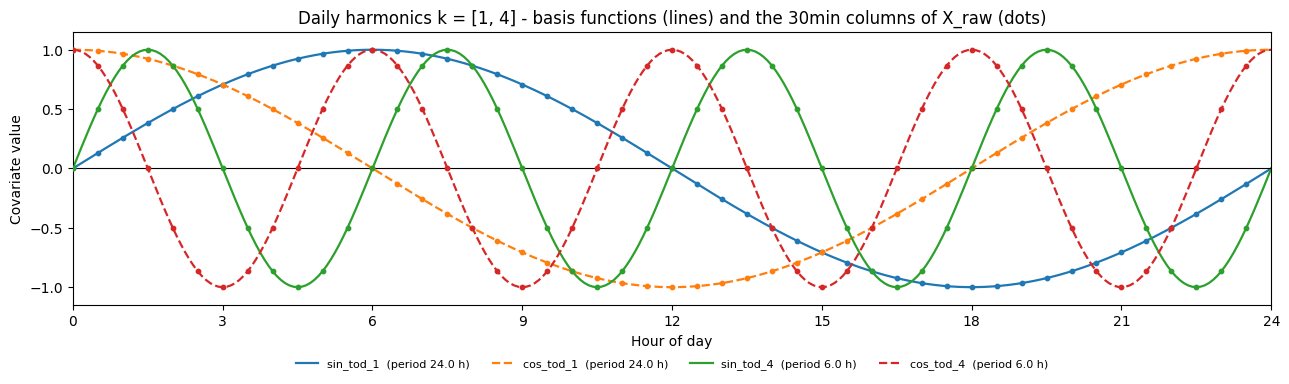

4 time-of-day columns: sin_tod_1, cos_tod_1, sin_tod_4, cos_tod_4


In [3]:
# ===================== The daily harmonics (time-of-day block) =====================
tod_h = harmonic_range(N_DAILY_CYCLES)
if not tod_h:
    print("N_DAILY_CYCLES is empty - there is no time-of-day block in the design matrix")
else:
    hours = np.linspace(0.0, 24.0, 24 * 12 + 1)          # dense grid, 5-minute steps
    angle = 2 * np.pi * hours / 24.0

    # The first 24 h of data, for the overlay. Hour-of-day is a function of the timestamp
    # alone, so the window needs no alignment - any full day samples the whole cycle.
    sel     = dates < dates[0] + pd.Timedelta(days=1)
    h_obs   = dates[sel].hour + dates[sel].minute / 60.0 + dates[sel].second / 3600.0
    ang_obs = 2 * np.pi * np.asarray(h_obs) / 24.0

    fig, ax = plt.subplots(figsize=(13, 4))
    for k in tod_h:
        for fn, style, np_fn in [("sin", "-", np.sin), ("cos", "--", np.cos)]:
            name = f"{fn}_tod_{k}"
            line, = ax.plot(hours, np_fn(k * angle), style, lw=1.6,
                            label=f"{name}  (period {24 / k:.1f} h)")
            col = covariate_cols.index(name)
            # The curve is the design matrix, not an illustration of it.
            assert np.allclose(X_raw[sel, col], np_fn(k * ang_obs), atol=1e-12)
            ax.scatter(h_obs, X_raw[sel, col], s=10, color=line.get_color(), zorder=3)

    ax.axhline(0.0, color="black", lw=0.8)
    ax.set(xlim=(0, 24), ylim=(-1.15, 1.15), xticks=np.arange(0, 25, 3),
           xlabel="Hour of day", ylabel="Covariate value",
           title=f"Daily harmonics k = {list(tod_h)} - basis functions (lines) and the "
                 f"{BIN} columns of X_raw (dots)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=min(4, 2 * len(tod_h)), fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()

    print(f"{2 * len(tod_h)} time-of-day columns: "
          f"{', '.join(f'{fn}_tod_{k}' for k in tod_h for fn in ('sin', 'cos'))}")


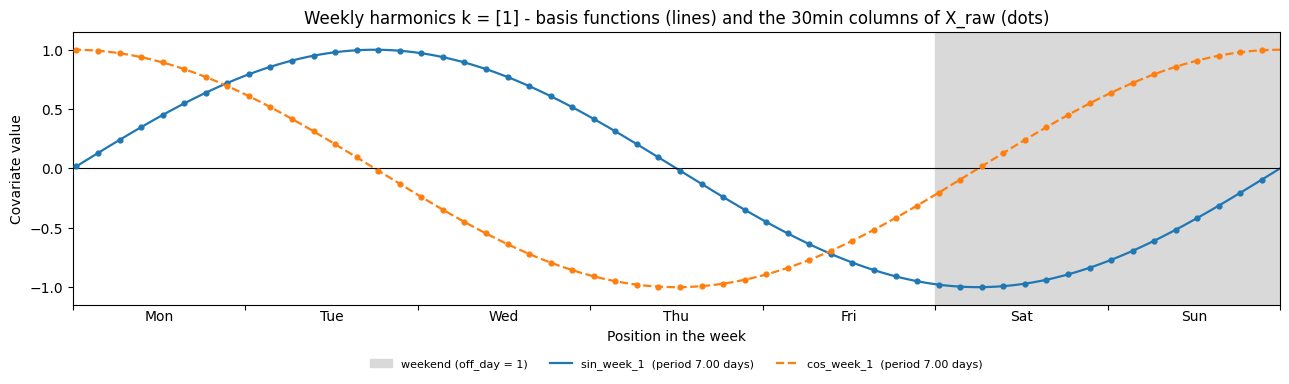

2 weekly columns: sin_week_1, cos_week_1
Note the weekly block is a smooth cycle: on its own it cannot switch a weekend on and off, which is why off_day is carried as its own flag / sequence splitter.


In [4]:
# ===================== The weekly harmonics (day-of-week block) =====================
week_h = harmonic_range(N_WEEKLY_CYCLES)
if not week_h:
    print("N_WEEKLY_CYCLES is empty - there is no weekly block in the design matrix")
else:
    days  = np.linspace(0.0, 7.0, 7 * 48 + 1)            # dense grid, 30-minute steps
    angle = 2 * np.pi * days / 7.0

    # Position in the week, counted from Monday 00:00 exactly as `build_covariates` does
    # (dayofweek * 86400 + time of day), so the first seven days of data cover every weekday
    # whatever day the series happens to start on.
    sel     = dates < dates[0] + pd.Timedelta(days=7)
    d_obs   = (dates[sel].dayofweek
               + (dates[sel].hour * 3600 + dates[sel].minute * 60 + dates[sel].second) / 86400.0)
    ang_obs = 2 * np.pi * np.asarray(d_obs) / 7.0
    # A week of fine bins is dense enough that every dot merges into the line, so the
    # overlay is thinned to roughly one dot every three hours. The check below still runs
    # over every bin.
    stride  = max(1, len(d_obs) // 56)

    fig, ax = plt.subplots(figsize=(13, 4))
    if USE_OFF_DAY:
        # What the harmonics are up against: the weekend the off_day flag marks outright.
        ax.axvspan(5.0, 7.0, color="0.85", zorder=0, label="weekend (off_day = 1)")
    for k in week_h:
        for fn, style, np_fn in [("sin", "-", np.sin), ("cos", "--", np.cos)]:
            name = f"{fn}_week_{k}"
            line, = ax.plot(days, np_fn(k * angle), style, lw=1.6,
                            label=f"{name}  (period {7 / k:.2f} days)")
            col = covariate_cols.index(name)
            assert np.allclose(X_raw[sel, col], np_fn(k * ang_obs), atol=1e-12)
            ax.scatter(d_obs[::stride], X_raw[sel, col][::stride], s=12,
                       color=line.get_color(), zorder=3)

    ax.axhline(0.0, color="black", lw=0.8)
    ax.set(xlim=(0, 7), ylim=(-1.15, 1.15), xlabel="Position in the week",
           ylabel="Covariate value",
           title=f"Weekly harmonics k = {list(week_h)} - basis functions (lines) and the "
                 f"{BIN} columns of X_raw (dots)")
    ax.set_xticks(np.arange(7) + 0.5, minor=True)
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], minor=True)
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels([])                                # weekday names sit on the minor ticks
    ax.tick_params(axis="x", which="minor", length=0)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=min(4, 2 * len(week_h) + 1), fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()

    print(f"{2 * len(week_h)} weekly columns: "
          f"{', '.join(f'{fn}_week_{k}' for k in week_h for fn in ('sin', 'cos'))}")
    print("Note the weekly block is a smooth cycle: on its own it cannot switch a weekend on and "
          "off, which is why off_day is carried as its own flag / sequence splitter.")


## Fit the three models

A warm-start chain, because the later fits do not converge from a cold start: the Gaussian fit
seeds the autoregressive one, which in turn is lifted to the second-order transition. The lift
is checked before it is fitted — at the seed the second-order model *is* the fitted AR model, so
their log-likelihoods must agree.

All three fits use the same tolerance and the same frozen parameter, so the AIC / BIC comparison
below is between models fitted under identical constraints.

In [5]:
FIT_TOL = 1e-2
FROZEN  = None #{"mu0": False}     # freeze the lowest state mean to avoid a degenerate state
FIT_KW  = dict(ys=ys_train, ts=None, xs=X_train_std, tol=FIT_TOL, frozen=FROZEN)

mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)).at[0].set(450)
sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(**FIT_KW)
print(f"  log-likelihood: {gauss_cov.log_likelihood():.4f}   converged: {gauss_cov.hmm_results.convergence}")

# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates ===")
ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov.emission, ys_train),
        jnp.exp(gauss_cov.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov.transition.transition_logits, gauss_cov.transition.beta),
    inital_distribution=init_dist,
)
ar_cov.fit(**FIT_KW)
print(f"  log-likelihood: {ar_cov.log_likelihood():.4f}   converged: {ar_cov.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov.emission.phi())}")

# --- 3. Second-order transition, lifted from the AR fit ----------------------------
print(f"=== Second-order (order {ORDER}) HMM + covariates ===")
AUG_STATES = STATES ** ORDER
# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current base
# state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma), so sigma and
# phi must be *tiled* (not repeated) to stay aligned with that convention.
so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(ar_cov.emission, ys_train)[:STATES],
        jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES),
        jnp.tile(ar_cov.emission.phi(), (1, STATES)),
    ),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the augmented
    # states, whose base-state marginal is the uniform used by the other two models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")
so_cov.fit(**FIT_KW)
print(f"  log-likelihood: {so_cov.log_likelihood():.4f}   converged: {so_cov.hmm_results.convergence}")

models = {"Gaussian + cov": gauss_cov, "Autoregressive + cov": ar_cov}#, #"Second-order + cov": so_cov}

=== Gaussian HMM + covariates ===
  log-likelihood: -16125.7318   converged: True
=== Autoregressive HMM + covariates ===
  log-likelihood: -13075.1807   converged: True
  phi (per state): [[ 0.30407061  0.42654968  0.73996502  0.98639496]
 [ 0.12178973  0.26785702  0.20004828 -0.23935925]
 [ 0.19603977  0.1370225  -0.05145055  0.11368515]
 [ 0.06596901  0.10397331  0.06699905 -0.08334433]
 [ 0.15604991  0.00821932  0.01417342  0.17855233]
 [ 0.08132652 -0.02375778 -0.04221559 -0.14109395]]
=== Second-order (order 2) HMM + covariates ===
  seed LL -13075.1807 vs AR+cov LL -13075.1807  (difference 0.00e+00)
  log-likelihood: -13015.5773   converged: True


In [6]:
ar_cov.emission.phi()

Array([[ 0.30407061,  0.42654968,  0.73996502,  0.98639496],
       [ 0.12178973,  0.26785702,  0.20004828, -0.23935925],
       [ 0.19603977,  0.1370225 , -0.05145055,  0.11368515],
       [ 0.06596901,  0.10397331,  0.06699905, -0.08334433],
       [ 0.15604991,  0.00821932,  0.01417342,  0.17855233],
       [ 0.08132652, -0.02375778, -0.04221559, -0.14109395]],      dtype=float64)

In [7]:
ar_cov.transition.beta

Array([[[ 7.20633474e+00, -9.59840606e-01, -7.59155774e-01],
        [ 1.30033442e+00, -6.89637685e+00, -1.94270489e+00],
        [ 3.63044373e-01,  1.98799870e+00, -6.27630668e+00],
        [ 3.37609750e+00,  3.35119592e+00, -3.91211475e-01]],

       [[ 2.08023850e+01,  4.38617581e+00,  3.98296832e+00],
        [ 1.04606263e+00, -8.74503664e-01, -1.19595613e+00],
        [ 9.43079270e-01,  8.58799869e-01, -9.25981723e-01],
        [ 9.82159041e-01,  1.00738723e+00, -6.42927782e-01]],

       [[ 1.13903427e+00,  5.79396181e-02, -2.03010525e+00],
        [ 6.46307825e-01,  6.03023165e-01,  1.02543168e+00],
        [ 2.87445732e+00, -3.00373881e-02,  3.24948339e-01],
        [ 2.46222443e+00,  2.50381434e+00,  4.97031225e-01]],

       [[ 1.91027824e+00,  2.72733843e+00, -3.65644236e-01],
        [-1.59158457e+00,  3.78230911e+00,  2.35440326e-01],
        [-1.18086567e+00, -1.13722642e+00,  4.97446446e+00],
        [ 1.12206383e+00,  1.15624368e+00, -1.24911105e+00]],

       [[-1.2625

## Residual and state diagnostics

Pseudo-residual diagnostics per model, then the decoded (most likely filtered) state over the
training block.

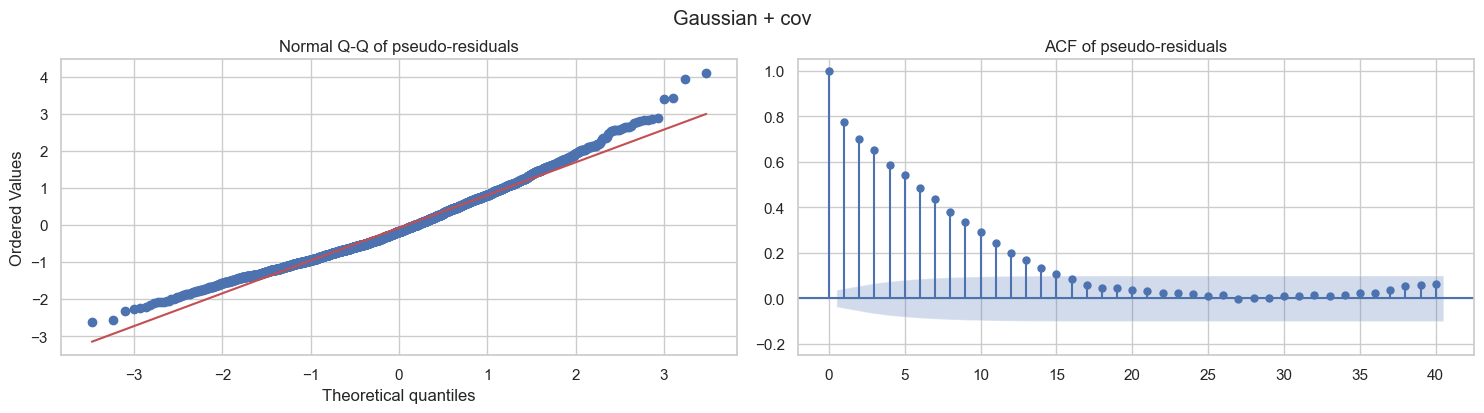

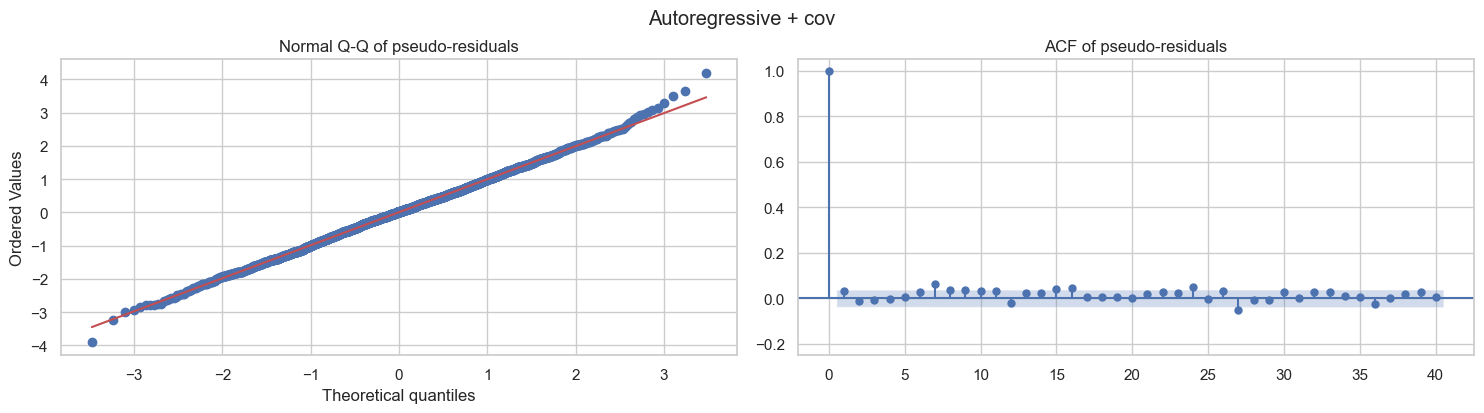

In [8]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

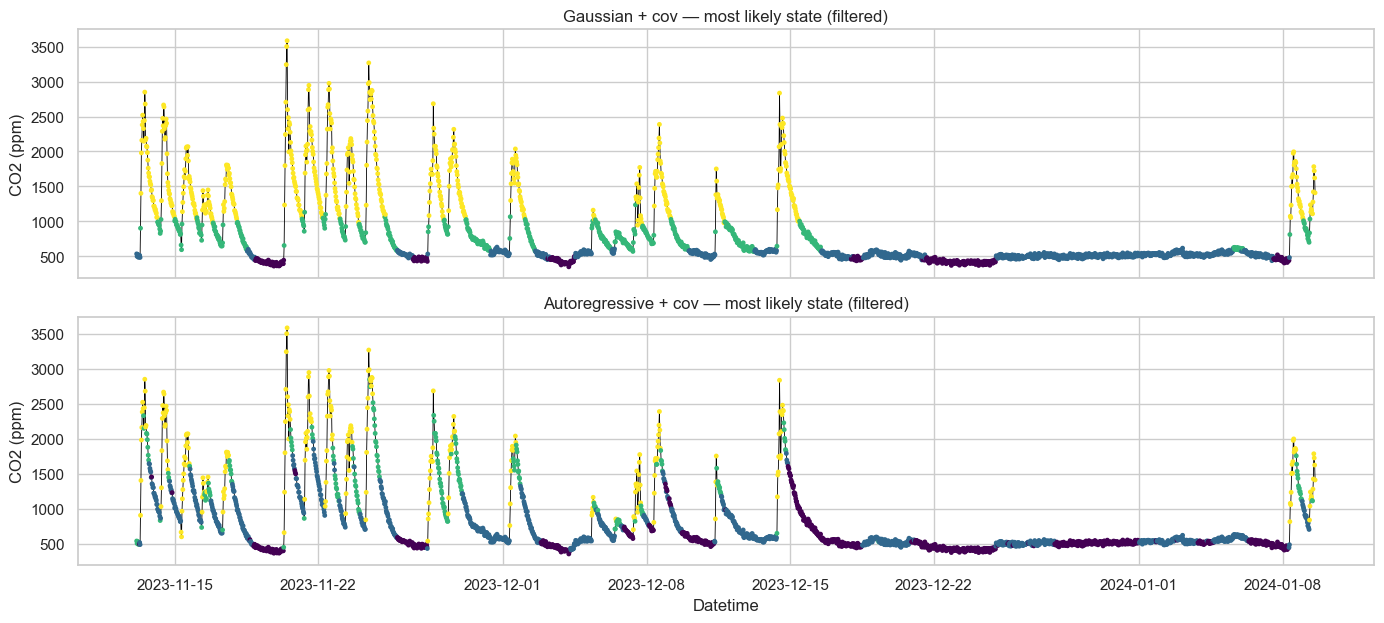

In [9]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order model
    # shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis", s=6, zorder=2)
    ax.set(title=f"{name} — most likely state (filtered)", ylabel="CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout(); plt.show()

## Rolling forecasts on the validation block

A fixed `HORIZON_HOURS`-ahead forecast anchored at *every* validation observation, against a
persistence baseline. The filtered state distribution at the anchor is propagated forward
through the covariate-driven transition matrices, and the emission mean is taken under the
resulting state distribution; for the autoregressive models each prediction is fed back in as
the next step's lag. Anchors stop `K` steps before the end of the block so every target lies
inside validation and nothing is scored against the training block.

In [10]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))

print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

start, end = TRAIN_IDX, len(ys)
forecasts = {"Persistence baseline": rolling_persistence(ys, start, end, K)}
for name, m in models.items():
    forecasts[name] = rolling_forecast(m, ys, X_std, start, end, K)

pred_table = pd.DataFrame([
    {"Model": name, "RMSE": rmse(yt, yp), "MAPE%": mape(yt, yp), "R2": r2_score(yt, yp), "n": len(yt)}
    for name, (idx, yt, yp, _sp) in forecasts.items()
]).sort_values("RMSE").reset_index(drop=True)

write_latex_table(pred_table.round(3), TABLE_DIR / "validation_forecast.tex",
                  caption=f"Rolling {HORIZON_HOURS}-hour-ahead validation forecast accuracy, "
                          f"{room_name} ({BIN}).",
                  label="tab:week5-validation-forecast")
pred_table.round(3)

Horizon: 6 h = 12 steps


,Model,RMSE,MAPE%,R2,n
0,Autoregressive + cov,361.217,20.605,0.614,625
1,Gaussian + cov,393.691,24.984,0.541,625
2,Persistence baseline,524.298,25.791,0.187,625


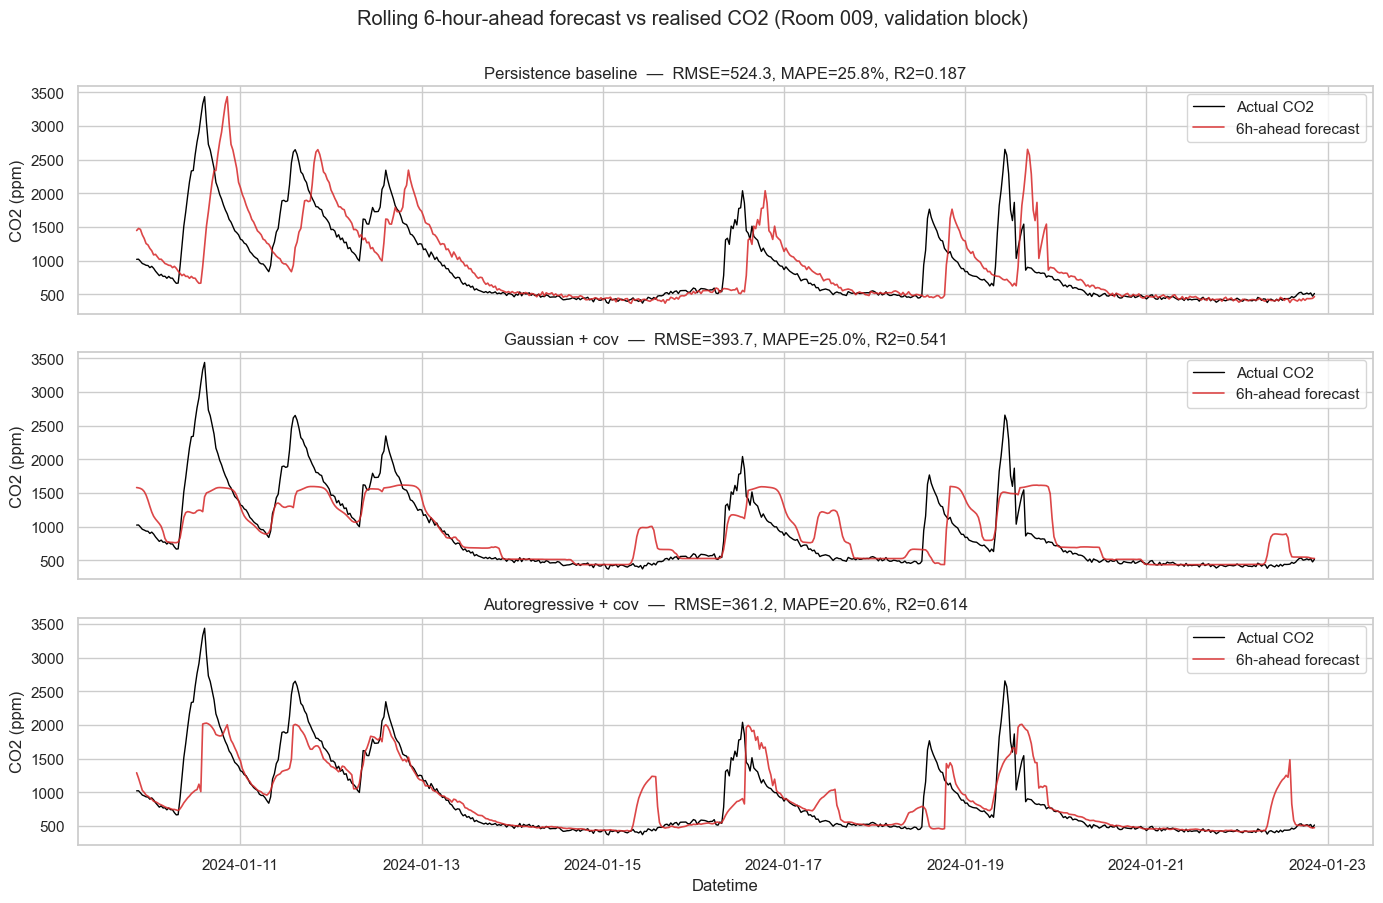

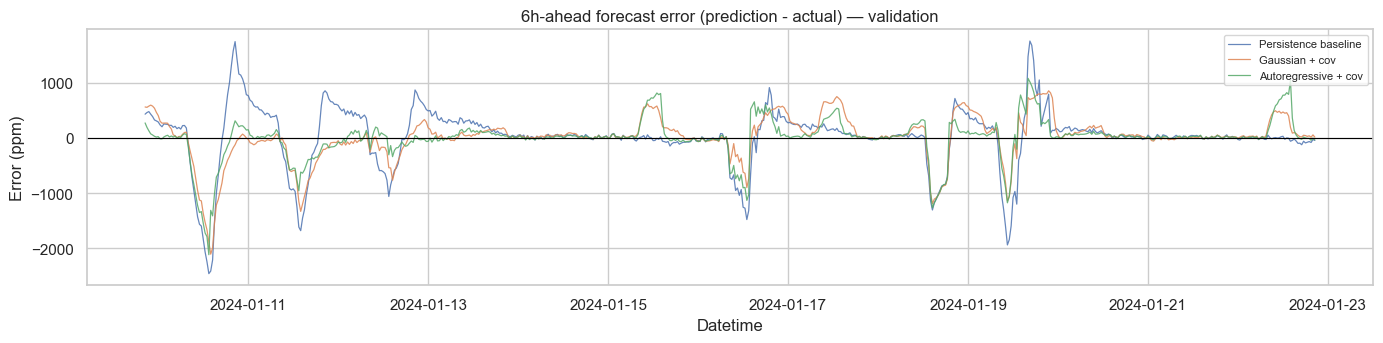

In [11]:
# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 3 * len(forecasts)), sharex=True)
for ax, (name, (idx, yt, yp, _sp)) in zip(np.atleast_1d(axes), forecasts.items()):
    ax.plot(dates[idx], yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(dates[idx], yp, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}", ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation block)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp, _sp) in forecasts.items():
    ax.plot(dates[idx], yp - yt, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — validation",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## Fitting the working-day runs as a batch

Off days cut the series into **runs of consecutive working days**. Treating the whole
training block as one sequence forces the chain to carry state across a weekend, which is
exactly the transition the covariates cannot explain. Each run is instead an independent
sequence sharing one parameter set, so the batch log-likelihood is the sum of the
per-run log-likelihoods.

The runs have different lengths (a normal week gives 5 working days, a week with a public
holiday fewer), so `batched=True` is handed a *list* of sequences. `ForwardAlgorithm.run`
pads them to a common length and masks the padding out: a padded step gets emission
density 1, hence a likelihood factor of exactly 1 and a log-likelihood contribution of
exactly 0.

In [12]:
# --- split the series into runs of consecutive working days -------------------------
import numpy as np

def working_day_runs(off_day) -> list[np.ndarray]:
    """Index groups of consecutive working-day bins.

    Returns the *indices* rather than the data, so `ys`, the covariates and the
    timestamps are all sliced with the same groups. Indexing the first axis directly is
    what makes this work for a 1-D `ys` and a 2-D covariate matrix alike: promoting a
    1-D `ys` with `jnp.atleast_2d` first would turn it into a single (1, N) row, and JAX
    *clamps* the out-of-range row indices instead of raising, so every run would come
    back as copies of the whole series.
    """
    off = np.asarray(off_day, dtype=bool)
    idx = np.flatnonzero(~off)
    breaks = np.flatnonzero(np.diff(idx) > 1) + 1
    return [g for g in np.split(idx, breaks) if len(g)]

if not USE_OFF_DAY:
    raise ValueError("this section splits on the off_day flag — set USE_OFF_DAY = True")

# Rebuilt here so the section stands on its own rather than on whatever X_raw happens
# to hold from an earlier run.
X_raw_b, cov_cols_b = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=WEATHER,
)

OFF_COL     = cov_cols_b.index("off_day")
off_day_all = X_raw_b[:, OFF_COL] == 1

# The flag is constant within a working-day run, so inside a run it cannot inform the
# transition at all: it is dropped from the design matrix and kept only as the splitter.
# (Note this drops a *column*, not a row — dropping a row would shift every covariate
# one bin out of alignment with ys.)
keep           = [j for j in range(X_raw_b.shape[1]) if j != OFF_COL]
Xb_std, _, _   = standardise(X_raw_b[:, keep], TRAIN_IDX)
Xb_std         = jnp.asarray(Xb_std)
cov_cols_batch = [cov_cols_b[j] for j in keep]
num_cov_batch  = Xb_std.shape[1]

# Runs within each block; validation indices are shifted back to absolute positions so
# they index `ys` and `dates` directly.
train_runs = working_day_runs(off_day_all[:TRAIN_IDX])
val_runs   = [g + TRAIN_IDX for g in working_day_runs(off_day_all[TRAIN_IDX:])]

ys_train_batch = [ys[g] for g in train_runs]
xs_train_batch = [Xb_std[g] for g in train_runs]
ys_val_batch   = [ys[g] for g in val_runs]
xs_val_batch   = [Xb_std[g] for g in val_runs]

BINS_PER_DAY = int(round(86400 / BIN_SECONDS))
for label, runs, batch in [("train", train_runs, ys_train_batch),
                           ("validation", val_runs, ys_val_batch)]:
    lengths = [len(g) for g in runs]
    padded  = len(lengths) * max(lengths)
    print(f"{label:<11} {len(runs):>3} runs, "
          f"{sum(lengths)} of {len(ys_train) if label == 'train' else len(ys_val)} bins kept, "
          f"lengths (working days): {[round(L / BINS_PER_DAY, 1) for L in lengths]}")
    print(f"{'':<11} padded to {max(lengths)} -> {padded - sum(lengths)} padded bins "
          f"({100 * (1 - sum(lengths) / padded):.1f}% of the batch, masked out of the likelihood)")

print(f"\ncovariates in the transition ({num_cov_batch}): {', '.join(cov_cols_batch)}")
assert all(len(y) == len(x) for y, x in zip(ys_train_batch, xs_train_batch))
assert all(y.ndim == 1 and x.ndim == 2 for y, x in zip(ys_train_batch, xs_train_batch))

train         9 runs, 1846 of 2758 bins kept, lengths (working days): [4.9, 5.0, 5.0, 5.0, 5.0, 5.0, 3.0, 4.0, 1.6]
            padded to 240 -> 314 padded bins (14.5% of the batch, masked out of the likelihood)
validation    3 runs, 445 of 637 bins kept, lengths (working days): [3.4, 5.0, 0.9]
            padded to 240 -> 275 padded bins (38.2% of the batch, masked out of the likelihood)

covariates in the transition (7): sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, sin_tod_4, cos_tod_4, mean_temp


## Fitting the two models on the batch

The same warm-start chain as the single-sequence fits: the Gaussian fit seeds the
autoregressive one. Both are fitted on the *batch* of working-day runs, so the
log-likelihoods here are comparable to each other but not to the single-sequence fits
above — they are computed over fewer observations (off days dropped) and without the
weekend transitions.

In [13]:
beta_init_batch = jnp.zeros((num_cov_batch, STATES, STATES - 1))
FIT_KW_BATCH    = dict(ts=None, tol=FIT_TOL, frozen=FROZEN, batched=True)

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates (working-day runs) ===")
gauss_cov_batch = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init_batch),
    inital_distribution=init_dist,
)
gauss_cov_batch.fit(ys=ys_train_batch, xs=xs_train_batch, **FIT_KW_BATCH)
print(f"  log-likelihood: {gauss_cov_batch.log_likelihood():.4f}   "
      f"converged: {gauss_cov_batch.hmm_results.convergence}")

# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates (working-day runs) ===")
ar_cov_batch = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov_batch.emission, ys_train_batch[0]),
        jnp.exp(gauss_cov_batch.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov_batch.transition.transition_logits,
                                 gauss_cov_batch.transition.beta),
    inital_distribution=init_dist,
)
ar_cov_batch.fit(ys=ys_train_batch, xs=xs_train_batch, **FIT_KW_BATCH)
print(f"  log-likelihood: {ar_cov_batch.log_likelihood():.4f}   "
      f"converged: {ar_cov_batch.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov_batch.emission.phi())}")

models_batch = {"Gaussian + cov (runs)": gauss_cov_batch,
                "Autoregressive + cov (runs)": ar_cov_batch}

# The padding must not have entered the likelihood: the batch log-likelihood has to equal
# the sum of the per-run log-likelihoods, each computed on its own unpadded sequence.
for name, m in models_batch.items():
    batched_ll = m.log_likelihood(ys_train_batch, xs=xs_train_batch, batched=True)
    summed_ll  = sum(m.log_likelihood(y, xs=x) for y, x in zip(ys_train_batch, xs_train_batch))
    print(f"{name}: batched {batched_ll:.6f} vs summed {summed_ll:.6f} "
          f"(diff {abs(batched_ll - summed_ll):.2e})")

=== Gaussian HMM + covariates (working-day runs) ===
  log-likelihood: -11363.1554   converged: True
=== Autoregressive HMM + covariates (working-day runs) ===
  log-likelihood: -8879.7419   converged: True
  phi (per state): [[ 0.29891723  0.42159805  0.71200493  0.99076331]
 [ 0.1297512   0.22847999  0.21800882 -0.19578282]
 [ 0.17581898  0.15224015 -0.04168475  0.08243929]
 [ 0.08353581  0.11201365  0.06324371 -0.08379772]
 [ 0.10774864  0.0068812   0.01473154  0.13159504]
 [ 0.13605297 -0.00834935 -0.03318792 -0.09767428]]
Gaussian + cov (runs): batched -11363.155400 vs summed -11363.155400 (diff 0.00e+00)
Autoregressive + cov (runs): batched -8879.741903 vs summed -8879.741903 (diff 1.82e-12)


## Rolling forecasts on the validation runs

The validation block is split into working-day runs the same way, and a fixed
`HORIZON_HOURS`-ahead forecast is anchored at every bin of every run. Each run is forecast
on its own — the filtered state at an anchor is built from that run's own history, so no
forecast reaches across an off-day gap, and no anchor in one run targets a bin in the next.

The scores are **pooled**: the targets and predictions of every run are concatenated and
scored once. That is not the same as averaging the per-run R2 values — pooling uses a
single variance over all validation targets, so a short run cannot weigh as much as a long
one, and a run whose own variance is small cannot produce a wildly negative R2 that drags
the mean down. The per-run spread is printed underneath so the pooled number is not hiding
it.

These numbers are **not comparable to the whole-block scores further up**: those include
off days, where CO2 sits flat at baseline and is trivially predictable, which inflates R2.
Everything here is scored on working days only.

In [14]:
# rolling_forecast needs start >= k - 1: below that, ys[anchors - j] indexes negatively
# and JAX *wraps*, silently taking a run's first anchors' lags from its last observations.
# One shared start for every model, so all of them are scored on identical anchors.
AR_START = AR_LAGS - 1
_pooled_models = {**models_batch, **models}
assert all(m.emission.phi().shape[0] == AR_LAGS
           for m in _pooled_models.values() if hasattr(m.emission, "phi")), \
    f"a fitted AR model disagrees with AR_LAGS={AR_LAGS} - re-run the fit cells"

print(f"Horizon: {HORIZON_HOURS} h = {K} steps; "
      f"{sum(1 for y in ys_val_batch if len(y) > K)} of {len(ys_val_batch)} validation runs "
      f"are longer than the horizon")

def pooled_run_forecast(model, runs, ys_batch, xs_batch):
    """Forecast every run separately, then pool the targets and predictions.

    `rolling_forecast` returns target indices *local* to the run it was given, so each is
    mapped back through the run's own index group to an absolute position in `ys` /
    `dates`. Without that the pooled series cannot be put on a time axis.
    """
    idx_all, yt_all, yp_all, sp_all, per_run = [], [], [], [], []
    for g, y_run, x_run in zip(runs, ys_batch, xs_batch):
        if len(y_run) <= K + AR_START:  # no anchor leaves a target inside the run
            continue
        local_idx, yt, yp, sp = rolling_forecast(model, y_run, x_run, AR_START, len(y_run), K)
        idx_all.append(np.asarray(g)[local_idx])
        yt_all.append(yt); yp_all.append(yp); sp_all.append(sp)
        per_run.append(r2_score(yt, yp))
    return (np.concatenate(idx_all), np.concatenate(yt_all),
            np.concatenate(yp_all), np.concatenate(sp_all), per_run)

def pooled_run_persistence(runs, ys_batch):
    idx_all, yt_all, yp_all, per_run = [], [], [], []
    for g, y_run in zip(runs, ys_batch):
        if len(y_run) <= K + AR_START:
            continue
        local_idx, yt, yp, _sp = rolling_persistence(y_run, AR_START, len(y_run), K)
        idx_all.append(np.asarray(g)[local_idx])
        yt_all.append(yt); yp_all.append(yp)
        per_run.append(r2_score(yt, yp))
    # No state distribution behind a persistence forecast -- None keeps the tuple shape.
    return (np.concatenate(idx_all), np.concatenate(yt_all),
            np.concatenate(yp_all), None, per_run)

pooled = {"Persistence baseline": pooled_run_persistence(val_runs, ys_val_batch)}
#Extend the batch notebook with the other models, so the pooled table has all of them

for name, m in models_batch.items():
    pooled[name] = pooled_run_forecast(m, val_runs, ys_val_batch, xs_val_batch)

xs_val_batch_full = [X_std[g] for g in val_runs]  # the batch notebook dropped the off_day column
for name, m in models.items():
    pooled[name] = pooled_run_forecast(m, val_runs, ys_val_batch, xs_val_batch_full)


val_table = pd.DataFrame([
    {"Model": name,
     "RMSE": rmse(yt, yp),
     "MAPE%": mape(yt, yp),
     "R2 (pooled)": r2_score(yt, yp),
     "R2 (per-run mean)": float(np.mean(per_run)),
     "R2 (per-run min)": float(np.min(per_run)),
     "Runs": len(per_run),
     "n": len(yt)}
    for name, (_idx, yt, yp, _sp, per_run) in pooled.items()
]).sort_values("RMSE").reset_index(drop=True)


for name, (_idx, yt, yp, _sp, per_run) in pooled.items():
    print(f"{name}: pooled R2 = {r2_score(yt, yp):.4f}  "
          f"per-run R2 = [{min(per_run):.3f}, {max(per_run):.3f}] over {len(per_run)} runs")

val_table.round(3)

Horizon: 6 h = 12 steps; 3 of 3 validation runs are longer than the horizon
Persistence baseline: pooled R2 = -0.0609  per-run R2 = [-0.947, -0.531] over 3 runs
Gaussian + cov (runs): pooled R2 = 0.4406  per-run R2 = [-35.205, 0.181] over 3 runs
Autoregressive + cov (runs): pooled R2 = 0.4853  per-run R2 = [-90.667, 0.315] over 3 runs
Gaussian + cov: pooled R2 = 0.4010  per-run R2 = [-49.329, 0.090] over 3 runs
Autoregressive + cov: pooled R2 = 0.4489  per-run R2 = [-213.554, 0.345] over 3 runs


,Model,RMSE,MAPE%,R2 (pooled),R2 (per-run mean),R2 (per-run min),Runs,n
0,Autoregressive + cov (runs),453.201,28.213,0.485,-30.103,-90.667,3,394
1,Autoregressive + cov,468.954,31.399,0.449,-71.070,-213.554,3,394
2,Gaussian + cov (runs),472.449,31.836,0.441,-11.681,-35.205,3,394
3,Gaussian + cov,488.882,33.691,0.401,-16.426,-49.329,3,394
4,Persistence baseline,650.631,32.919,-0.061,-0.778,-0.947,3,394


## Forecast vs realised over the validation runs

The same view as the whole-block forecast plots further up, restricted to the validation
working-day runs. The x axis is wall time, so the off-day gaps between runs are visible as
breaks: the lines are split there rather than drawn straight across, since no forecast
spans a gap.

This is the genuinely out-of-sample view. It is the one to judge the models on — an
in-sample plot of the *filtered* mean would look far tighter without meaning anything,
because the filtered state at bin t is conditioned on y_t itself.

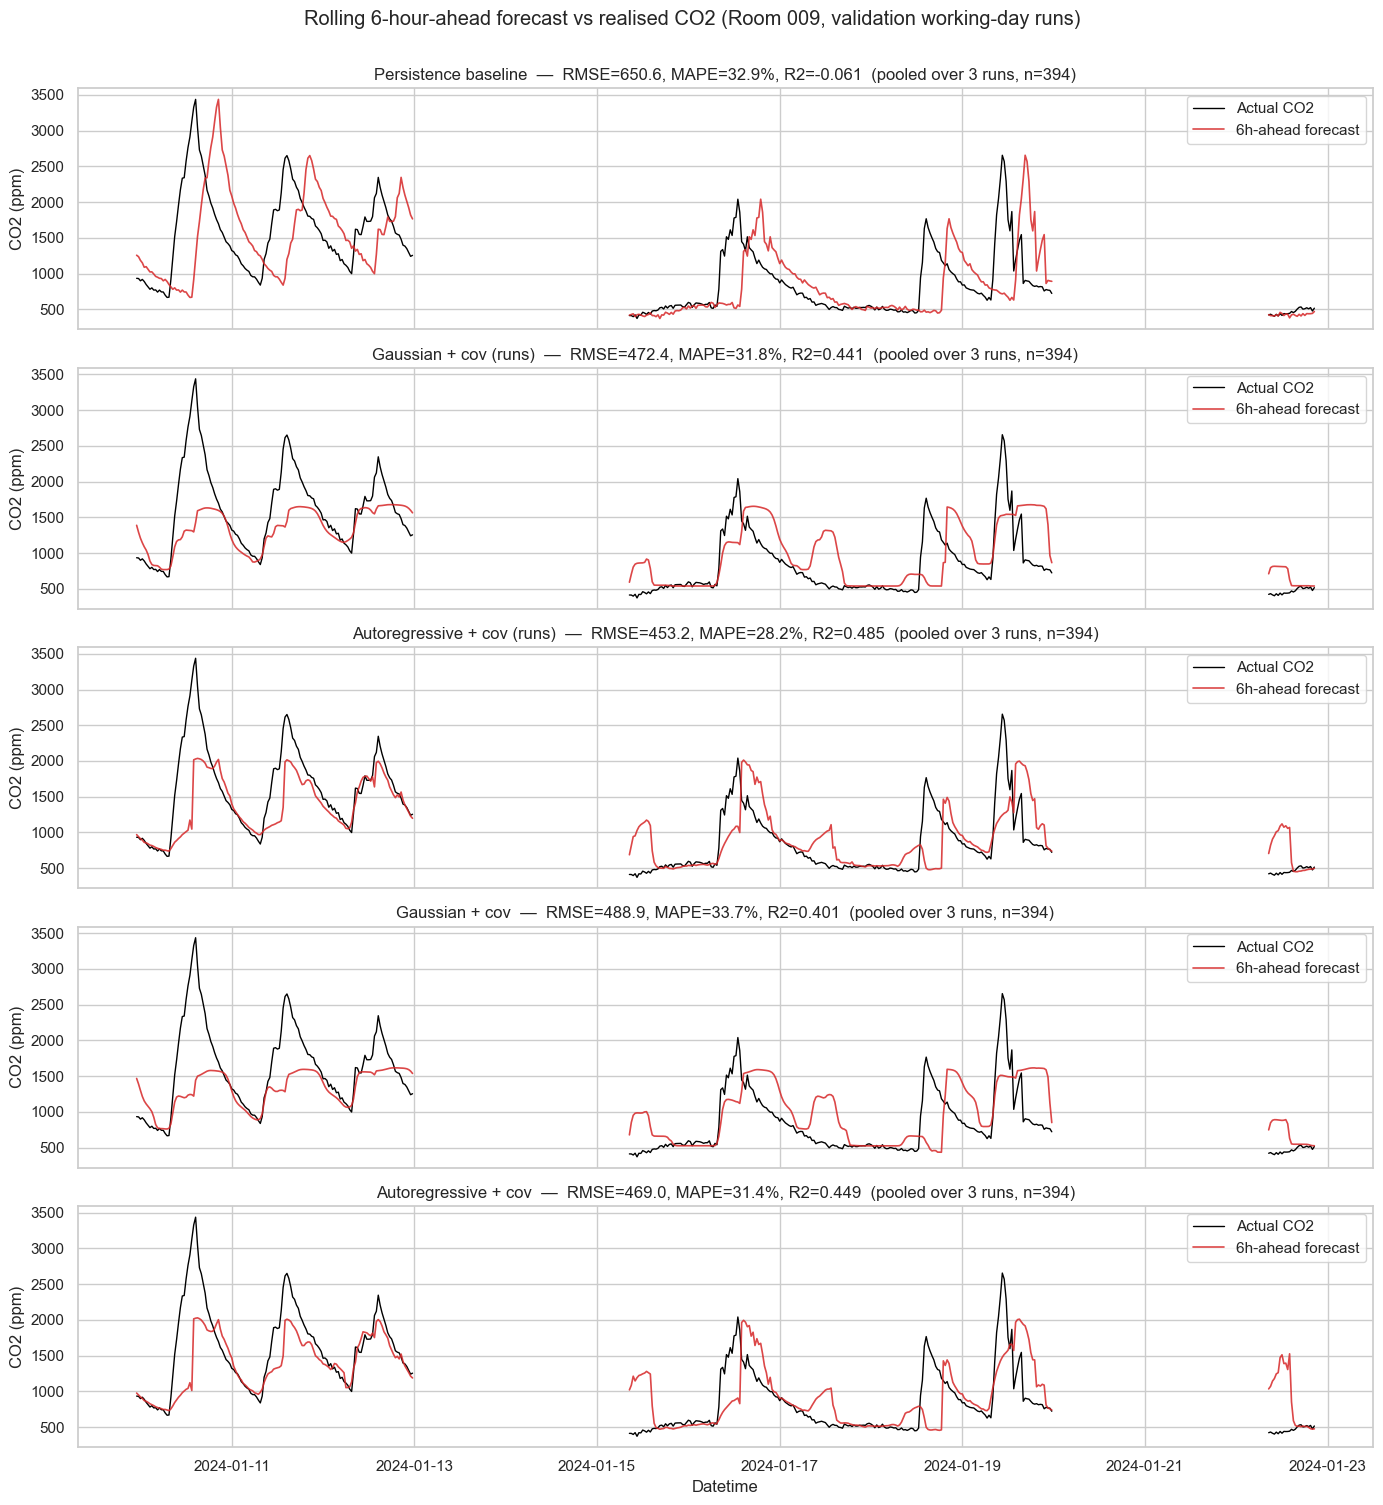

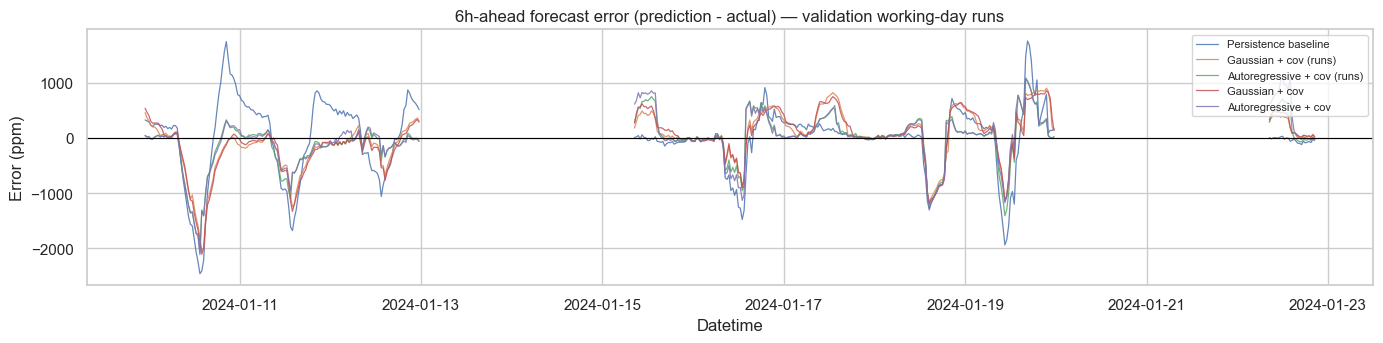

In [15]:
def break_at_gaps(idx, values):
    """Split a pooled series at run boundaries so no line bridges an off-day gap.

    A NaN is inserted wherever the absolute index jumps by more than one bin; matplotlib
    lifts the pen there.
    """
    idx    = np.asarray(idx)
    values = np.asarray(values, dtype=float)
    jumps  = np.flatnonzero(np.diff(idx) > 1) + 1
    d, v   = list(dates[idx]), list(values)
    for k in reversed(jumps):                       # back to front, so earlier positions hold
        d.insert(k, dates[idx[k - 1]] + pd.Timedelta(BIN))
        v.insert(k, np.nan)
    return pd.DatetimeIndex(d), np.asarray(v)

# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(pooled), 1, figsize=(14, 3 * len(pooled)), sharex=True)
for ax, (name, (idx, yt, yp, _sp, per_run)) in zip(np.atleast_1d(axes), pooled.items()):
    d, yt_g = break_at_gaps(idx, yt)
    _, yp_g = break_at_gaps(idx, yp)
    ax.plot(d, yt_g, color="black", lw=1.0, label="Actual CO2")
    ax.plot(d, yp_g, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}  (pooled over {len(per_run)} runs, n={len(yt)})",
           ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation working-day runs)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp, _sp, _per_run) in pooled.items():
    d, err = break_at_gaps(idx, yp - yt)
    ax.plot(d, err, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — "
             f"validation working-day runs",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## State probabilities over the first validation week

The forward pass is run over the **whole** validation sequence, so the probabilities below
carry the full history behind them rather than restarting at the window edge; only the plot is
cut to the first seven days. Each band is the probability the chain is in that state at that
bin, so the bands sum to 1 at every point, and CO2 sits on the secondary axis.

`STATE_KIND` chooses the distribution: `"predictive"` is `u_{t|t-1}`, which has not yet seen
`y_t`, and `"filtered"` is `u_{t|t}`, which has.

Autoregressive + cov — predictive probabilities over 637 validation bins


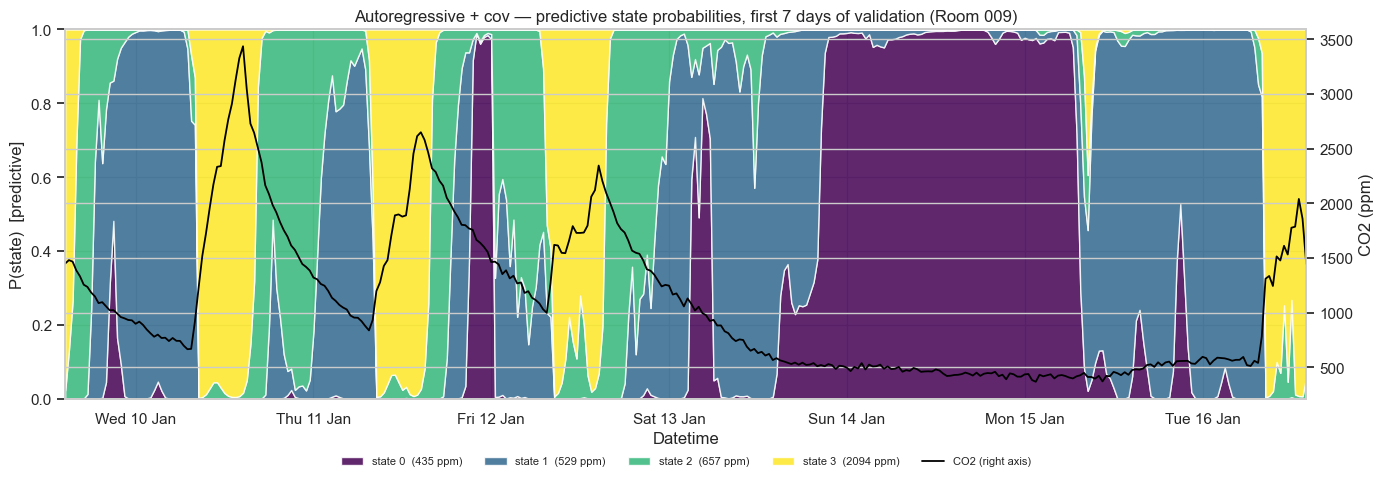

mean probability over the plotted week:
  state 0 (mu =   434.5 ppm): phi = 
  state 1 (mu =   528.5 ppm): phi = 
  state 2 (mu =   656.7 ppm): phi = 
  state 3 (mu =  2094.2 ppm): phi = 


In [16]:
# ===================== State probabilities over the first validation week =============
STATE_PLOT_MODEL = "Autoregressive + cov"   # any key of `models` or `models_batch`
STATE_KIND       = "predictive"             # "predictive" (u_t|t-1) or "filtered" (u_t|t)
WEEK_DAYS        = 7
# ==================================================================================

import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from src.api.v4 import ForwardAlgorithm

_all_models = {**models, **models_batch}
if STATE_PLOT_MODEL not in _all_models:
    raise KeyError(f"unknown model {STATE_PLOT_MODEL!r}; choose one of {list(_all_models)}")
_model    = _all_models[STATE_PLOT_MODEL]
_is_batch = STATE_PLOT_MODEL in models_batch


def state_probs(model, ys_seq, xs_seq, kind):
    """Per-bin state probabilities, folded onto the STATES base states.

    A second-order model's augmented index encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES +
    s_t, so summing the augmented probabilities over s_{t-1} gives the marginal over the
    current base state -- which is what is comparable across all the models here.
    """
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys_seq, ts=None, xs=xs_seq)
    u   = np.asarray(out.ut if kind == "predictive" else out.utt).reshape(len(ys_seq), -1)
    return u.reshape(len(ys_seq), -1, STATES).sum(axis=1)


# --- run over the whole validation sequence ---------------------------------------
if _is_batch:
    v_idx   = np.concatenate([np.asarray(g) for g in val_runs])
    v_probs = np.concatenate([state_probs(_model, y_run, x_run, STATE_KIND)
                              for y_run, x_run in zip(ys_val_batch, xs_val_batch)])
else:
    # One pass over train+validation, keeping the validation tail: the filter reaches the
    # split carrying the training history rather than starting cold there.
    v_idx   = np.arange(TRAIN_IDX, len(ys))
    v_probs = state_probs(_model, ys, X_std, STATE_KIND)[TRAIN_IDX:]

#  clips the likelihood factor at 1e-10 (forward_algorithm.py:133). Where an
# observation is so unlikely that the true factor underflows that floor, the row it divides is
# left summing to less than 1 -- harmless for the likelihood, but a stackplot of unnormalised
# rows would understate every band. Renormalise for the plot and say how often it bit: a
# non-trivial count means the model is being badly surprised, which is worth knowing.
row_sum = v_probs.sum(axis=1, keepdims=True)
clamped = np.flatnonzero(np.abs(row_sum[:, 0] - 1.0) > 1e-6)
v_probs = v_probs / row_sum
print(f"{STATE_PLOT_MODEL} — {STATE_KIND} probabilities over {len(v_idx)} validation bins")
if len(clamped):
    print(f"  note: {len(clamped)} bin(s) hit the 1e-10 likelihood-factor floor and were "
          f"renormalised (worst row sum {row_sum[:, 0].min():.3g}) — "
          f"the model assigns those observations essentially zero density")

# --- cut the first week out for plotting ------------------------------------------
week_to = dates[v_idx[0]] + pd.Timedelta(days=WEEK_DAYS)
in_week = dates[v_idx] < week_to
w_idx, w_probs = v_idx[in_week], v_probs[in_week]
w_dates, w_co2 = dates[w_idx], np.asarray(ys)[w_idx]
mu = np.asarray(state_means(_model.emission, ys_train))[:STATES]

fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.get_cmap("viridis", STATES)
ax.stackplot(w_dates, *w_probs.T, colors=[cmap(s) for s in range(STATES)], alpha=0.85,
             labels=[f"state {s}  ({m:.0f} ppm)" for s, m in enumerate(mu)])
ax.set(ylim=(0, 1), xlim=(w_dates[0], w_dates[-1]),
       ylabel=f"P(state)  [{STATE_KIND}]", xlabel="Datetime",
       title=f"{STATE_PLOT_MODEL} — {STATE_KIND} state probabilities, first {WEEK_DAYS} days "
             f"of validation ({room_name})")

ax2 = ax.twinx()
ax2.plot(w_dates, w_co2, color="black", lw=1.3)
ax2.set_ylabel("CO2 (ppm)")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="black", lw=1.3)); labels.append("CO2 (right axis)")
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=STATES + 1, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print(f"mean probability over the plotted week:")

for s, m in enumerate(mu):
    print(f"  state {s} (mu = {m:7.1f} ppm): phi = ")


## Forecasted state probabilities vs observed CO2

The bands above were the *filtered* state distribution — conditioned on the observation at the same
bin. These are the **forecast** distributions instead: `rolling_forecast` now returns, for every
target, the K-step-ahead state distribution the predictive mean was averaged over, i.e.
P(state at t+K | history up to t). It is the state belief the model actually forecasts CO2 from, so
laying it against the realised CO2 at the same bins shows whether the model anticipates an
occupancy build-up or only recognises it after the fact.

These come from `forecasts`, not `pooled`: the whole validation block run as **one contiguous
sequence** (off days included, no run splitting), so the bands are unbroken across the plotted week
and every target's belief carries the full history behind it. The run-split version is what the
pooled table above scores; it is not what is drawn here.


Autoregressive + cov - 6h-ahead state distributions over 625 validation targets (336 in the plotted week), one contiguous sequence


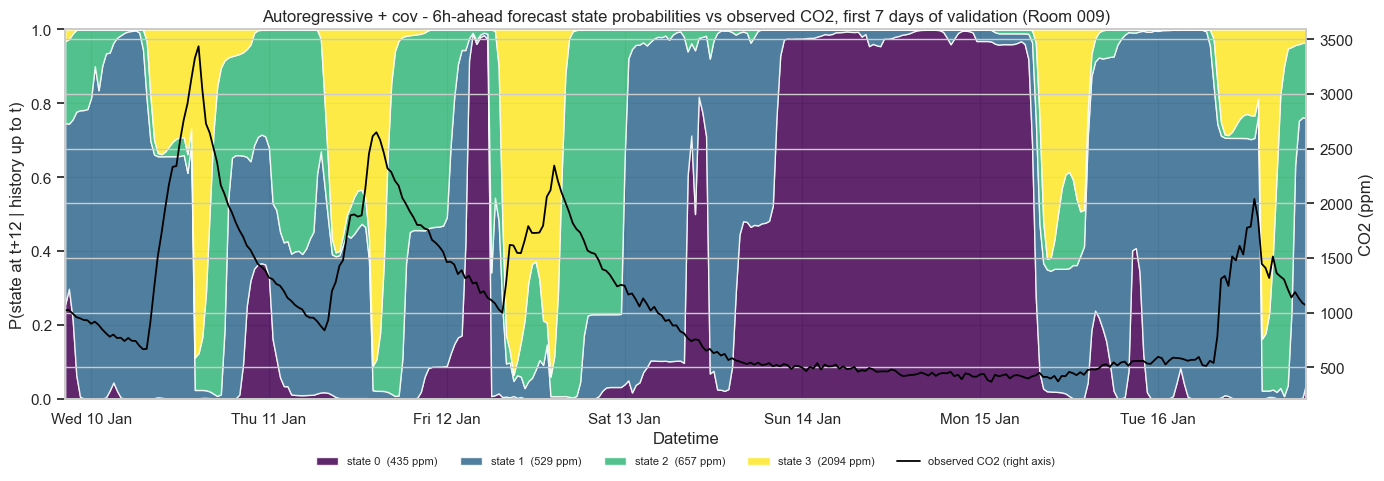


over the plotted week - mean forecast probability and its correlation with observed CO2:

  state 0 (mu =   434.5 ppm), phi = [0.304 0.122 0.196 0.066 0.156 0.081]: 
  state 1 (mu =   528.5 ppm), phi = [ 0.427  0.268  0.137  0.104  0.008 -0.024]: 
  state 2 (mu =   656.7 ppm), phi = [ 0.74   0.2   -0.051  0.067  0.014 -0.042]: 
  state 3 (mu =  2094.2 ppm), phi = [ 0.986 -0.239  0.114 -0.083  0.179 -0.141]: 


In [23]:
# ====== Forecasted (K-step-ahead) state probabilities vs observed CO2, one sequence ======
FORECAST_STATE_MODEL = "Autoregressive + cov"   # any key of `forecasts` except the baseline
FORECAST_WEEK_DAYS   = 7                        # days from the start of validation to show
# ========================================================================================

import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# `forecasts` holds the *unbatched* forecast: one `rolling_forecast` call over the whole
# contiguous train+validation series, anchored at every validation bin. `pooled` would give
# the same models forecast run by run, which is the scored view but is cut at every off day.
if FORECAST_STATE_MODEL not in forecasts:
    raise KeyError(f"unknown model {FORECAST_STATE_MODEL!r}; choose one of {list(forecasts)}")

f_idx, f_obs, f_pred, f_probs = forecasts[FORECAST_STATE_MODEL]
if f_probs is None:
    raise ValueError(f"{FORECAST_STATE_MODEL!r} is the persistence baseline - it has no states")

# Same 1e-10 likelihood-factor floor as the filtered plot above: a row that hit it sums to
# less than 1, which would understate every band. Renormalise and report how often it bit.
f_row_sum = f_probs.sum(axis=1, keepdims=True)
f_clamped = np.flatnonzero(np.abs(f_row_sum[:, 0] - 1.0) > 1e-6)
f_probs   = f_probs / f_row_sum

# --- cut the first week of forecast targets out -----------------------------------
f_to    = dates[f_idx[0]] + pd.Timedelta(days=FORECAST_WEEK_DAYS)
in_week = dates[f_idx] < f_to
w_idx   = f_idx[in_week]
w_probs = f_probs[in_week]
w_obs   = f_obs[in_week]
w_dates = dates[w_idx]
mu_fc   = np.asarray(state_means(models[FORECAST_STATE_MODEL].emission, ys_train))[:STATES]

# One sequence, so the plotted window must be gap-free - a stackplot cannot lift the pen.
assert np.all(np.diff(w_idx) == 1), "the plotted window is not contiguous"

print(f"{FORECAST_STATE_MODEL} - {HORIZON_HOURS}h-ahead state distributions over "
      f"{len(f_idx)} validation targets ({len(w_idx)} in the plotted week), "
      f"one contiguous sequence")
if len(f_clamped):
    print(f"  note: {len(f_clamped)} target(s) hit the 1e-10 likelihood-factor floor and were "
          f"renormalised (worst row sum {f_row_sum[:, 0].min():.3g})")

fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.get_cmap("viridis", STATES)
ax.stackplot(w_dates, *w_probs.T, colors=[cmap(s) for s in range(STATES)], alpha=0.85,
             labels=[f"state {s}  ({m:.0f} ppm)" for s, m in enumerate(mu_fc)])
ax.set(ylim=(0, 1), xlim=(w_dates[0], w_dates[-1]),
       ylabel=f"P(state at t+{K} | history up to t)", xlabel="Datetime",
       title=f"{FORECAST_STATE_MODEL} - {HORIZON_HOURS}h-ahead forecast state probabilities vs "
             f"observed CO2, first {FORECAST_WEEK_DAYS} days of validation ({room_name})")

ax2 = ax.twinx()
ax2.plot(w_dates, w_obs, color="black", lw=1.3)
ax2.set_ylabel("CO2 (ppm)")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="black", lw=1.3)); labels.append("observed CO2 (right axis)")
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=STATES + 1, fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

# How informative the forecast belief is about the realised level: the correlation of each
# state's forecast probability with the CO2 actually observed at that bin.
print(f"\nover the plotted week - mean forecast probability and its correlation with observed CO2:")
print()
phi = np.asarray(models[FORECAST_STATE_MODEL].emission.phi())
for s, m in enumerate(mu_fc):
    corr = np.corrcoef(w_probs[:, s], w_obs)[0, 1] if w_probs[:, s].std() > 0 else np.nan
    print(f"  state {s} (mu = {m:7.1f} ppm), phi = {phi[:, s ].round(3)}: ")
